#Drive Mount

In [ ]:
# ====================================
# STEP 1: Google Drive Mount & Dataset Setup
# ====================================

from google.colab import drive
import os
import cv2
import pandas as pd


from google.colab import drive
drive.mount('/content/drive')


# Mount Google Drive
drive.mount('/content/drive')

# Define base project path in Google Drive
BASE_PATH = "/content/drive/MyDrive/CrowdStampedeAnalysis"
DATASET_PATH = os.path.join(BASE_PATH, "datasets")
VIDEO_PATH = os.path.join(DATASET_PATH, "videos")
META_PATH = os.path.join(DATASET_PATH, "metadata")

# Create folders if they don't exist
os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(VIDEO_PATH, exist_ok=True)
os.makedirs(META_PATH, exist_ok=True)

print("✅ Google Drive mounted and project folders created!")

Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted and project folders created!


# STEP 1 - DATA PREPARATION

In [ ]:
"""
STEP 1: Data Preparation
------------------------
Loads dataset paths, extracts metadata, prepares frame directories,
and ensures all project structure components are in sync.
"""

import os
import cv2
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ============ CONFIGURATION ============ #

PROJECT_ROOT = Path("/content/drive/MyDrive/CrowdStampedeAnalysis")
EXTRACTED_DIR = PROJECT_ROOT / "extracted"
METADATA_DIR = PROJECT_ROOT / "/content/drive/MyDrive/CrowdStampedeAnalysis/datasets/metadata"
FRAMES_DIR = PROJECT_ROOT / "frames"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

# Video metadata CSV file
VIDEO_METADATA_CSV = METADATA_DIR / "all_video_metadata.csv"



In [ ]:
# ====================================== #

def ensure_directories():
    """Ensure required directories exist."""
    for d in [FRAMES_DIR, RESULTS_DIR, RESULTS_DIR / "density_maps"]:
        os.makedirs(d, exist_ok=True)
    print("✅ Directory structure verified.")


def extract_video_metadata():
    """
    Extract or validate video metadata.
    If metadata CSV exists, load it. Otherwise, generate it from extracted videos.
    """
    if VIDEO_METADATA_CSV.exists():
        print(f"📂 Found existing metadata file: {VIDEO_METADATA_CSV}")
        metadata = pd.read_csv(VIDEO_METADATA_CSV)
    else:
        print("⚙️ Generating new metadata file...")
        metadata_rows = []
        video_dirs = [EXTRACTED_DIR / "UMN", EXTRACTED_DIR / "UCSD", EXTRACTED_DIR / "Extra"]
        video_files = []

        for root_dir in video_dirs:
            for ext in ["*.avi", "*.mp4", "*.mov"]:
                video_files.extend(root_dir.rglob(ext))

        for vf in tqdm(video_files, desc="Extracting video metadata"):
            try:
                cap = cv2.VideoCapture(str(vf))
                fps = cap.get(cv2.CAP_PROP_FPS)
                frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                duration = frame_count / fps if fps else 0

                metadata_rows.append({
                    "video_name": vf.stem,
                    "video_path": str(vf),
                    "dataset": vf.parents[1].name,
                    "fps": fps,
                    "frame_count": frame_count,
                    "duration_sec": duration,
                    "width": width,
                    "height": height
                })
                cap.release()
            except Exception as e:
                print(f"⚠️ Error reading {vf}: {e}")

        metadata = pd.DataFrame(metadata_rows)
        metadata.to_csv(VIDEO_METADATA_CSV, index=False)
        print(f"✅ Metadata saved: {VIDEO_METADATA_CSV}")

    return metadata


def extract_frames(metadata, max_frames=None):
    """
    Extract frames for each video and save them under /frames/{dataset}/{video_name}/
    - max_frames: limit for fast testing; None = extract all
    """
    for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Extracting frames"):
        video_path = row["video_path"]
        dataset = row["dataset"]
        video_name = row["video_name"]

        output_dir = FRAMES_DIR / dataset / video_name
        os.makedirs(output_dir, exist_ok=True)

        if any(output_dir.glob("*.jpg")):
            continue  # Skip already processed videos

        cap = cv2.VideoCapture(video_path)
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_path = output_dir / f"frame_{frame_idx:05d}.jpg"
            cv2.imwrite(str(frame_path), frame)
            frame_idx += 1

            if max_frames and frame_idx >= max_frames:
                break

        cap.release()

    print(f"🎞️ Frame extraction completed and stored under {FRAMES_DIR}")


def verify_models():
    """Ensure pretrained models exist for CSRNet & MCNN."""
    required_models = [
        MODELS_DIR / "csrnet_pretrained.pth",
        MODELS_DIR / "mcnn_shtechA_660.h5"
    ]
    for model_path in required_models:
        if model_path.exists():
            print(f"✅ Model found: {model_path.name}")
        else:
            print(f"❌ Missing model: {model_path.name}")




In [ ]:
# ============ MAIN EXECUTION ============ #

if __name__ == "__main__":
    ensure_directories()
    metadata = extract_video_metadata()
    extract_frames(metadata, max_frames=None)  # You can set e.g., max_frames=50 for testing
    verify_models()

    print("\n🚀 STEP 1 — Data Preparation Completed Successfully!")


✅ Directory structure verified.
📂 Found existing metadata file: /content/drive/MyDrive/CrowdStampedeAnalysis/datasets/metadata/all_video_metadata.csv


Extracting frames: 100%|██████████| 40/40 [10:04<00:00, 15.12s/it]

🎞️ Frame extraction completed and stored under /content/drive/MyDrive/CrowdStampedeAnalysis/frames
✅ Model found: csrnet_pretrained.pth
✅ Model found: mcnn_shtechA_660.h5

🚀 STEP 1 — Data Preparation Completed Successfully!


In [ ]:
# ====================================
# Install YOLOv8 and dependencies
# ====================================
!pip install ultralytics opencv-python pandas matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.7 MB/s eta 0:00:00


#Step 2 - Detection (YOLOv8 / Local Detector)

In [ ]:
import os
import re
import pandas as pd
from tqdm import tqdm
import difflib

# === CONFIGURATION ===
BASE_DIR = '/content/drive/MyDrive/CrowdStampedeAnalysis/datasets'
DETECTIONS_DIR = os.path.join(BASE_DIR, '/content/drive/MyDrive/CrowdStampedeAnalysis/detections')
METADATA_FILE = os.path.join(BASE_DIR, 'metadata', 'all_video_metadata.csv')
CORRECTIONS_FILE = os.path.join(BASE_DIR, 'metadata', 'id_corrections.csv')
OUTPUT_SUFFIX = '_scaled.csv'
MATCH_REPORT = os.path.join(BASE_DIR, 'metadata', 'detection_metadata_match_report.csv')

# === LOAD METADATA ===
metadata = pd.read_csv(METADATA_FILE)
metadata.columns = [c.strip().lower() for c in metadata.columns]
metadata['video_name_clean'] = metadata['video_name'].astype(str).str.lower().str.replace(r'[^a-z0-9]+', '', regex=True)

# === LOAD EXISTING CORRECTIONS IF ANY ===
if os.path.exists(CORRECTIONS_FILE):
    corrections_df = pd.read_csv(CORRECTIONS_FILE)
else:
    corrections_df = pd.DataFrame(columns=['detection_core_id', 'corrected_video_name', 'source'])

# === Helper: Save corrections ===
def save_corrections(df):
    df.to_csv(CORRECTIONS_FILE, index=False)

# === Helper: Extract core ID from detection filename ===
def extract_core_id(filename):
    name = os.path.splitext(filename)[0].lower()
    name = re.sub(r'(_l|_c)?_detections.*$', '', name)
    name = re.sub(r'(abnormal|normal|crowddataset|extra|crowd|dataset|-)+', ' ', name)
    name = re.sub(r'[^a-z0-9\-]+', ' ', name).strip()
    match = re.search(r'([a-z]*\d+[-]?\d*[a-z]*)$', name)
    if match:
        return match.group(1).strip('-_ ')
    return name

# === Helper: Find metadata row (with correction + fuzzy fallback) ===
def find_best_metadata_match(file_basename):
    core_id = extract_core_id(file_basename)
    clean_id = core_id.lower().replace('-', '').replace('_', '')

    # 1️⃣ Check existing correction table first
    corrected_entry = corrections_df[corrections_df['detection_core_id'].str.lower() == core_id.lower()]
    if not corrected_entry.empty:
        corrected_name = corrected_entry.iloc[0]['corrected_video_name']
        match_row = metadata[metadata['video_name'] == corrected_name]
        if not match_row.empty:
            return match_row.iloc[0], core_id, "from_correction"

    # 2️⃣ Direct exact match
    direct_match = metadata[metadata['video_name_clean'].str.replace('-', '').str.contains(clean_id)]
    if len(direct_match) >= 1:
        matched_row = direct_match.iloc[0]
        # Store this new correction for future use
        corrections_df.loc[len(corrections_df)] = [core_id, matched_row['video_name'], "auto-learned"]
        return matched_row, core_id, "auto_learned_exact"

    # 3️⃣ Fuzzy match fallback
    possible_matches = metadata['video_name_clean'].tolist()
    best = difflib.get_close_matches(clean_id, possible_matches, n=1, cutoff=0.6)
    if best:
        matched_row = metadata.loc[metadata['video_name_clean'] == best[0]].iloc[0]
        corrections_df.loc[len(corrections_df)] = [core_id, matched_row['video_name'], "auto-learned"]
        return matched_row, core_id, "auto_learned_fuzzy"

    return None, core_id, None

# === Helper: Scale detections ===
def scale_detections(df, meta_row):
    width = meta_row.get('width', meta_row.get('frame_width', None))
    height = meta_row.get('height', meta_row.get('frame_height', None))
    if width is None or height is None:
        raise ValueError("Missing width/height in metadata.")
    for col in df.columns:
        if 'x' in col.lower():
            df[col] = df[col].clip(0, width)
        if 'y' in col.lower():
            df[col] = df[col].clip(0, height)
    return df

# === MAIN EXECUTION ===
match_records = []
all_files = [f for f in os.listdir(DETECTIONS_DIR) if f.endswith('.csv')]
print(f"\n📂 Found {len(all_files)} detection files.\n")

for fname in tqdm(all_files, desc="Scaling detections"):
    fpath = os.path.join(DETECTIONS_DIR, fname)
    try:
        df = pd.read_csv(fpath)
    except Exception as e:
        print(f"❌ Error reading {fname}: {e}")
        match_records.append([fname, None, "Read Error"])
        continue

    meta_row, core_id, match_type = find_best_metadata_match(fname)
    if meta_row is None:
        print(f"⚠️  Metadata missing for {fname}, skipping scaling.")
        match_records.append([fname, None, "No Match"])
        continue

    try:
        scaled_df = scale_detections(df, meta_row)
        output_path = os.path.join(DETECTIONS_DIR, os.path.splitext(fname)[0] + OUTPUT_SUFFIX)
        scaled_df.to_csv(output_path, index=False)
        match_records.append([fname, meta_row['video_name'], match_type])
    except Exception as e:
        print(f"❌ Error scaling {fname}: {e}")
        match_records.append([fname, meta_row['video_name'], f"Scaling Error: {e}"])

# === SAVE MATCH REPORT + CORRECTIONS ===
match_df = pd.DataFrame(match_records, columns=["Detection File", "Matched Metadata", "Status"])
match_df.to_csv(MATCH_REPORT, index=False)
save_corrections(corrections_df.drop_duplicates(subset=['detection_core_id']))

print("\n✅ Scaling complete.")
print(f"📄 Match report saved to: {MATCH_REPORT}")
print(f"💾 Corrections file saved to: {CORRECTIONS_FILE}")


📂 Found 88 detection files.



Scaling detections: 100%|██████████| 88/88 [00:05<00:00, 15.67it/s]



✅ Scaling complete.
📄 Match report saved to: /content/drive/MyDrive/CrowdStampedeAnalysis/datasets/metadata/detection_metadata_match_report.csv
💾 Corrections file saved to: /content/drive/MyDrive/CrowdStampedeAnalysis/datasets/metadata/id_corrections.csv


# Step 3: Object Tracking and Motion Computation

In [ ]:
!pip install lap filterpy scikit-image torch torchvision ultralytics supervision


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 10.2 MB/s eta 0:00:00
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=852263543b586002674c9d4ad0256c84364474f3158ad6a7daec5de8ce555a52
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


In [ ]:
!pip install deep_sort_realtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 49.4 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.spatial import distance

# ==========================================================
# CONFIGURATION
# ==========================================================
FRAMES_DIR = "/content/drive/MyDrive/CrowdStampedeAnalysis/frames"
DETECTIONS_DIR = "/content/drive/MyDrive/CrowdStampedeAnalysis/detections"
OUTPUT_DIR = "/content/drive/MyDrive/CrowdStampedeAnalysis/tracks_fixed_v2"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================
def load_detections(detection_file):
    """Load and validate detection CSV."""
    df = pd.read_csv(detection_file)
    df.columns = [c.strip().lower() for c in df.columns]
    required = {"frame_id", "x1", "y1", "x2", "y2"}
    if not required.issubset(df.columns):
        print(f"⚠️ Missing columns in {detection_file}")
        return None
    df = df.dropna(subset=["x1", "y1", "x2", "y2"])
    df = df[df["x2"] > df["x1"]]
    df = df[df["y2"] > df["y1"]]
    if df.empty:
        print(f"⚠️ Empty detections in {detection_file}")
        return None
    return df


def match_frame_folder(detection_file):
    """Match detection file with corresponding frame folder."""
    base_name = os.path.basename(detection_file).split("_detections")[0]
    for root, dirs, _ in os.walk(FRAMES_DIR):
        for d in dirs:
            if d.lower() in base_name.lower():
                return os.path.join(root, d)
    return None


def compute_adaptive_threshold(frame_w=640, frame_h=480, factor=0.15):
    """Compute adaptive centroid match distance."""
    diag = np.sqrt(frame_w**2 + frame_h**2)
    return diag * factor  # 15% of frame diagonal


def compute_tracks(detections, frame_w=640, frame_h=480):
    """Improved centroid-based tracker with adaptive threshold."""
    tracks = []
    track_id = 0
    active_tracks = {}
    velocity = {}

    max_distance = compute_adaptive_threshold(frame_w, frame_h)

    for frame_id, frame_data in detections.groupby("frame_id"):
        frame_boxes = frame_data[["x1", "y1", "x2", "y2"]].values
        centroids = np.array([[np.mean([x1, x2]), np.mean([y1, y2])] for x1, y1, x2, y2 in frame_boxes])

        new_active = {}
        matched_ids = set()

        for i, centroid in enumerate(centroids):
            best_tid = None
            best_dist = float("inf")

            # Predict next centroid if velocity known
            for tid, prev_centroid in active_tracks.items():
                pred = prev_centroid + velocity.get(tid, np.array([0, 0]))
                dist = distance.euclidean(centroid, pred)
                if dist < best_dist and dist < max_distance:
                    best_tid = tid
                    best_dist = dist

            if best_tid is not None:
                # Update track
                tracks.append([frame_id, best_tid, centroid[0], centroid[1]])
                velocity[best_tid] = centroid - active_tracks[best_tid]
                new_active[best_tid] = centroid
                matched_ids.add(best_tid)
            else:
                # Create new track
                track_id += 1
                tracks.append([frame_id, track_id, centroid[0], centroid[1]])
                new_active[track_id] = centroid
                velocity[track_id] = np.array([0, 0])

        # Retain only active tracks
        active_tracks = new_active

    tracks_df = pd.DataFrame(tracks, columns=["frame_id", "track_id", "cx", "cy"])
    return tracks_df


# ==========================================================
# MAIN PIPELINE
# ==========================================================
def process_all_videos():
    detection_files = [os.path.join(DETECTIONS_DIR, f) for f in os.listdir(DETECTIONS_DIR) if f.endswith(".csv")]
    print(f"📂 Found {len(detection_files)} detection files.\n")

    all_tracks = []

    for detection_file in tqdm(detection_files):
        detections = load_detections(detection_file)
        if detections is None:
            continue

        frame_folder = match_frame_folder(detection_file)
        if not frame_folder:
            print(f"⚠️ No matching frame folder for {os.path.basename(detection_file)}")
            continue

        # Estimate frame size from first frame if available
        sample_frame = None
        for f in os.listdir(frame_folder):
            if f.lower().endswith((".jpg", ".png")):
                sample_frame = cv2.imread(os.path.join(frame_folder, f))
                break
        if sample_frame is not None:
            h, w = sample_frame.shape[:2]
        else:
            h, w = 480, 640  # default

        print(f"📸 Matched: {frame_folder} | Frame size: {w}x{h}")

        tracks = compute_tracks(detections, w, h)
        if tracks.empty:
            print(f"⚠️ No valid tracks for {os.path.basename(detection_file)}")
            continue

        video_name = os.path.basename(detection_file).replace("_detections.csv", "")
        out_path = os.path.join(OUTPUT_DIR, f"{video_name}_tracks.csv")
        tracks.to_csv(out_path, index=False)
        all_tracks.append(tracks)

        print(f"💾 Saved {len(tracks)} tracks → {out_path}")

    if all_tracks:
        combined = pd.concat(all_tracks, ignore_index=True)
        combined.to_csv(os.path.join(OUTPUT_DIR, "all_videos_tracks.csv"), index=False)
        print(f"✅ Combined track file saved. Total entries: {len(combined)}")
    else:
        print("⚠️ No valid tracks generated.")


# ==========================================================
if __name__ == "__main__":
    process_all_videos()


📂 Found 128 detection files.



  0%|          | 0/128 [00:00<?, ?it/s]

📸 Matched: /content/drive/MyDrive/CrowdStampedeAnalysis/frames/Normal Crowds | Frame size: 640x480


  1%|          | 1/128 [00:00<00:34,  3.66it/s]

💾 Saved 253 tracks → /content/drive/MyDrive/CrowdStampedeAnalysis/tracks_fixed_v2/Normal Crowds_341-46_l_tracks.csv
📸 Matched: /content/drive/MyDrive/CrowdStampedeAnalysis/frames/Normal Crowds | Frame size: 640x480


...

 98%|█████████▊| 126/128 [00:20<00:00,  7.51it/s]

💾 Saved 1901 tracks → /content/drive/MyDrive/CrowdStampedeAnalysis/tracks_fixed_v2/Abnormal Crowds_263C044_064_c_detections_scaled_scaled_scaled.csv_tracks.csv
📸 Matched: /content/drive/MyDrive/CrowdStampedeAnalysis/frames/Normal Crowds | Frame size: 640x480
💾 Saved 459 tracks → /content/drive/MyDrive/CrowdStampedeAnalysis/tracks_fixed_v2/Abnormal Crowds_3452204_031_c_detections_scaled_scaled_scaled.csv_tracks.csv
📸 Matched: /content/drive/MyDrive/CrowdStampedeAnalysis/frames/Crowd Dataset - extra | Frame size: 640x480


100%|██████████| 128/128 [00:21<00:00,  6.07it/s]

💾 Saved 3168 tracks → /content/drive/MyDrive/CrowdStampedeAnalysis/tracks_fixed_v2/Crowd Dataset - extra_UCF_tailgating_part_NGA_1.00_detections_scaled_scaled_scaled.csv_tracks.csv


✅ Combined track file saved. Total entries: 79473


#STEP 4 – Counting and Density Estimation

In [ ]:
# ============================================================
# Robust loader: inspect .h5, try Keras load_weights, fallback
# to manual mapping, and fallback to PyTorch CSRNet if present.
# ============================================================
import os
import h5py
import numpy as np
import traceback

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models, Input

# PyTorch fallback
import torch
import torch.nn as nn

# =============================================================================
# 1) Build MCNN (functional API) — same as earlier
# =============================================================================
def build_mcnn_model():
    input_img = Input(shape=(None, None, 3), name="input_image")

    # Column 1
    x1 = layers.Conv2D(16, (9, 9), activation='relu', padding='same')(input_img)
    x1 = layers.MaxPooling2D(2)(x1)
    x1 = layers.Conv2D(32, (7, 7), activation='relu', padding='same')(x1)
    x1 = layers.MaxPooling2D(2)(x1)
    x1 = layers.Conv2D(16, (7, 7), activation='relu', padding='same')(x1)
    x1 = layers.Conv2D(8, (7, 7), activation='relu', padding='same')(x1)

    # Column 2
    x2 = layers.Conv2D(20, (7, 7), activation='relu', padding='same')(input_img)
    x2 = layers.MaxPooling2D(2)(x2)
    x2 = layers.Conv2D(40, (5, 5), activation='relu', padding='same')(x2)
    x2 = layers.MaxPooling2D(2)(x2)
    x2 = layers.Conv2D(20, (5, 5), activation='relu', padding='same')(x2)
    x2 = layers.Conv2D(10, (5, 5), activation='relu', padding='same')(x2)

    # Column 3
    x3 = layers.Conv2D(24, (5, 5), activation='relu', padding='same')(input_img)
    x3 = layers.MaxPooling2D(2)(x3)
    x3 = layers.Conv2D(48, (3, 3), activation='relu', padding='same')(x3)
    x3 = layers.MaxPooling2D(2)(x3)
    x3 = layers.Conv2D(24, (3, 3), activation='relu', padding='same')(x3)
    x3 = layers.Conv2D(12, (3, 3), activation='relu', padding='same')(x3)

    merged = layers.Concatenate(name="concat")([x1, x2, x3])
    output = layers.Conv2D(1, (1, 1), activation='linear', padding='same', name="density_map")(merged)
    model = models.Model(inputs=input_img, outputs=output, name="MCNN")
    return model

# =============================================================================
# 2) HDF5 inspector
# =============================================================================
def inspect_h5(h5_path, out_report_path=None):
    report_lines = []
    print("Inspecting HDF5 file:", h5_path)
    report_lines.append(f"Inspecting {h5_path}\n")
    try:
        with h5py.File(h5_path, 'r') as f:
            def print_group(name, obj):
                info = f"- {name} : {type(obj)}"
                report_lines.append(info)
            f.visititems(lambda name, obj: report_lines.append(f"{name} - {type(obj)}"))
            # top-level keys
            report_lines.append("\nTop-level keys:")
            for k in f.keys():
                report_lines.append(f"  - {k}")
            # attrs
            report_lines.append("\nTop-level attributes:")
            for k, v in f.attrs.items():
                report_lines.append(f"  - {k}: {v}")
    except Exception as e:
        report_lines.append(f"ERROR reading HDF5: {e}\n{traceback.format_exc()}")

    # print summary
    print("\n".join(report_lines[:200]))  # print first chunk to console
    if out_report_path:
        with open(out_report_path, 'w') as fo:
            fo.write("\n".join(report_lines))
        print("Saved HDF5 inspection report to:", out_report_path)
    return report_lines

# =============================================================================
# 3) Try normal Keras load_weights
# =============================================================================
def try_keras_load_weights(model, h5path):
    try:
        model.load_weights(h5path)
        print("✅ model.load_weights() succeeded.")
        return True
    except Exception as e:
        print("❌ model.load_weights() failed:", repr(e))
        return False



In [ ]:
# =============================================================================
# 4) Manual weights extraction and attempt to map by order/shape (best-effort)
#    — Extract all numeric arrays from the HDF5 and try to set them
# =============================================================================
def extract_arrays_from_h5(h5path):
    arrays = []
    names = []
    try:
        with h5py.File(h5path, 'r') as f:
            def visit(name, node):
                # node is a dataset if it's an h5py.Dataset
                if isinstance(node, h5py.Dataset):
                    try:
                        arr = node[()]
                        if isinstance(arr, (np.ndarray,)):
                            arrays.append(arr)
                            names.append(name)
                    except Exception:
                        pass
            f.visititems(visit)
    except Exception as e:
        print("Error reading arrays from h5:", e)
    print(f"Found {len(arrays)} numeric arrays in HDF5 (first 20 names):", names[:20])
    return names, arrays

def try_manual_map_keras(model, h5path, verbose=True):
    # Get model layers that have weights
    layers_with_weights = [L for L in model.layers if L.get_weights()]
    if verbose:
        print("Model has", len(layers_with_weights), "layers with weights (expect to map).")

    names, arrays = extract_arrays_from_h5(h5path)
    if len(arrays) == 0:
        print("No numeric arrays found in HDF5 to map.")
        return False

    # Flatten arrays by shape to list and attempt to group into layer sets
    # Approach (best-effort):
    #   For each layer in order, get required weights shapes (list of arrays),
    #   then try to consume arrays from the extracted list with matching shapes.
    arr_idx = 0
    mapped = {}
    try:
        for L in layers_with_weights:
            required_shapes = [w.shape for w in L.get_weights()]
            if verbose:
                print(f"Layer `{L.name}` needs shapes: {required_shapes}")
            to_set = []
            for rs in required_shapes:
                # look ahead in arrays list for a matching shape
                found = False
                for j in range(arr_idx, len(arrays)):
                    if arrays[j].shape == rs:
                        to_set.append(arrays[j])
                        # swap to current arr_idx position to consume it
                        arrays[j], arrays[arr_idx] = arrays[arr_idx], arrays[j]
                        arr_idx += 1
                        found = True
                        break
                if not found:
                    # shape mismatch — give up for this layer mapping
                    print(f"Could not find matching array for shape {rs} (layer {L.name}). Aborting manual map.")
                    return False
            # if we reached here, assign weights to layer
            L.set_weights(to_set)
            mapped[L.name] = True
            if verbose:
                print(f"Mapped weights for layer {L.name}")
        print("✅ Manual mapping succeeded for all mapped layers.")
        return True
    except Exception as e:
        print("❌ Manual mapping failed:", e)
        print(traceback.format_exc())
        return False

# =============================================================================
# 5) PyTorch CSRNet fallback (define minimal CSRNet and load .pth if present)
# =============================================================================
class CSRNet(nn.Module):
    def __init__(self, load_weights=False):
        super(CSRNet, self).__init__()
        # Simple CSRNet-like frontend: use VGG-like conv layers (not pretrained here)
        self.frontend = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),
        )
        self.backend = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1, dilation=2), nn.ReLU(True),
            nn.Conv2d(512, 512, 3, padding=1, dilation=2), nn.ReLU(True),
            nn.Conv2d(512, 512, 3, padding=1, dilation=2), nn.ReLU(True),
            nn.Conv2d(512, 256, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(256, 128, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(128, 1, 1), # density output
            nn.ReLU(True)
        )

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        return x

def try_pytorch_csrnet(pth_path):
    try:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = CSRNet().to(device)
        ckpt = torch.load(pth_path, map_location=device)
        if isinstance(ckpt, dict) and 'state_dict' in ckpt:
            state = ckpt['state_dict']
        else:
            state = ckpt
        # try state dict load
        model.load_state_dict(state)
        model.eval()
        print("✅ Loaded PyTorch CSRNet weights from", pth_path)
        return model
    except Exception as e:
        print("❌ Failed to load PyTorch CSRNet:", e)
        return None



In [ ]:
# =============================================================================
# 6) Orchestration: try everything and report
# =============================================================================
def robust_weight_loader(h5_path, keras_model, fallback_pth=None, report_dir=None):
    if not os.path.exists(h5_path):
        print("HDF5 weights file not found:", h5_path)
        return {"status": "missing_file"}

    # Step A: inspect file and save report
    report_path = os.path.join(report_dir, "h5_inspect_report.txt") if report_dir else None
    inspect_h5(h5_path, out_report_path=report_path)

    # Step B: try normal keras load_weights
    ok = try_keras_load_weights(keras_model, h5_path)
    if ok:
        # quick forward pass test
        import numpy as np
        try:
            sample = np.random.rand(1, 128, 128, 3).astype(np.float32)
            out = keras_model.predict(sample, verbose=0)
            print("Forward pass output shape:", out.shape)
            return {"status": "keras_loaded"}
        except Exception as e:
            print("Warning: forward pass failed after load_weights:", e)
            return {"status": "keras_loaded_forward_failed"}

    # Step C: try manual mapping
    print("\nAttempting manual mapping of arrays from HDF5 -> model layers (best-effort).")
    ok2 = try_manual_map_keras(keras_model, h5_path, verbose=True)
    if ok2:
        print("Manual mapping succeeded, testing forward pass...")
        try:
            import numpy as np
            sample = np.random.rand(1, 128, 128, 3).astype(np.float32)
            out = keras_model.predict(sample, verbose=0)
            print("Forward pass output shape after manual mapping:", out.shape)
            return {"status": "manual_mapping_loaded"}
        except Exception as e:
            print("Manual mapping loaded but forward pass failed:", e)
            return {"status": "manual_loaded_forward_failed"}

    # Step D: fallback to PyTorch CSRNet if available
    if fallback_pth and os.path.exists(fallback_pth):
        print("\nHDF5 mapping failed. Attempting PyTorch CSRNet fallback using:", fallback_pth)
        pt_model = try_pytorch_csrnet(fallback_pth)
        if pt_model is not None:
            return {"status": "pytorch_loaded", "model": pt_model}
        else:
            print("PyTorch fallback failed.")

    # Step E: nothing worked
    print("\nAll automated loading attempts failed. Next steps:")
    print("  - Ensure you have a Keras `.h5` saved with model.save(...) (architecture+weights), OR")
    print("  - Provide Keras weights saved via `model.save_weights(...)` producing layer groups, OR")
    print("  - Provide the PyTorch `.pth` for CSRNet and we can use that instead.")
    return {"status": "failed"}

# =============================================================================
# 7) Run the robust loader now
# =============================================================================
BASE = "/content/drive/MyDrive/CrowdStampedeAnalysis"
H5_FILE = os.path.join(BASE, "models", "mcnn_shtechA_660.h5")
PTH_FALLBACK = os.path.join(BASE, "models", "csrnet_pretrained.pth")
REPORT_DIR = os.path.join(BASE, "models")

keras_model = build_mcnn_model()
result = robust_weight_loader(H5_FILE, keras_model, fallback_pth=PTH_FALLBACK, report_dir=REPORT_DIR)

print("\n=== RESULT SUMMARY ===")
print(result)


Inspecting HDF5 file: /content/drive/MyDrive/CrowdStampedeAnalysis/models/mcnn_shtechA_660.h5
Inspecting /content/drive/MyDrive/CrowdStampedeAnalysis/models/mcnn_shtechA_660.h5

DME.branch1.0.conv.bias - <class 'h5py._hl.dataset.Dataset'>
DME.branch1.0.conv.weight - <class 'h5py._hl.dataset.Dataset'>
DME.branch1.2.conv.bias - <class 'h5py._hl.dataset.Dataset'>
DME.branch1.2.conv.weight - <class 'h5py._hl.dataset.Dataset'>
DME.branch1.4.conv.bias - <class 'h5py._hl.dataset.Dataset'>
DME.branch1.4.conv.weight - <class 'h5py._hl.dataset.Dataset'>
DME.branch1.5.conv.bias - <class 'h5py._hl.dataset.Dataset'>
DME.branch1.5.conv.weight - <class 'h5py._hl.dataset.Dataset'>
DME.branch2.0.conv.bias - <class 'h5py._hl.dataset.Dataset'>
DME.branch2.0.conv.weight - <class 'h5py._hl.dataset.Dataset'>
DME.branch2.2.conv.bias - <class 'h5py._hl.dataset.Dataset'>
DME.branch2.2.conv.weight - <class 'h5py._hl.dataset.Dataset'>
DME.branch2.4.conv.bias - <class 'h5py._hl.dataset.Dataset'>
DME.branch2.4.con

##PyTorch MCNN + HDF5 Weight Loader

In [ ]:
import torch
import torch.nn as nn
import h5py
import numpy as np
import os

# ==================================================
# 1️⃣ MCNN Definition — ShanghaiTech-A Compatible
# ==================================================

class ConvRelu(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv(x))


class MCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.branch1 = nn.Sequential(
            ConvRelu(1, 16, 9, 4),
            nn.MaxPool2d(2),
            ConvRelu(16, 32, 7, 3),
            nn.MaxPool2d(2),
            ConvRelu(32, 16, 7, 3),
            ConvRelu(16, 8, 7, 3),
        )

        self.branch2 = nn.Sequential(
            ConvRelu(1, 20, 7, 3),
            nn.MaxPool2d(2),
            ConvRelu(20, 40, 5, 2),
            nn.MaxPool2d(2),
            ConvRelu(40, 20, 5, 2),
            ConvRelu(20, 10, 5, 2),
        )

        self.branch3 = nn.Sequential(
            ConvRelu(1, 24, 5, 2),
            nn.MaxPool2d(2),
            ConvRelu(24, 48, 3, 1),
            nn.MaxPool2d(2),
            ConvRelu(48, 24, 3, 1),
            ConvRelu(24, 12, 3, 1),
        )

        # Final density map fusion (1x1 conv)
        self.fuse = nn.Sequential(
            nn.Conv2d(8 + 10 + 12, 1, 1)
        )

    def forward(self, x):
        x1 = self.branch1(x)
        x2 = self.branch2(x)
        x3 = self.branch3(x)
        x_cat = torch.cat((x1, x2, x3), dim=1)
        return self.fuse(x_cat)


# ==================================================
# 2️⃣ Utility: Recursive HDF5 Key Search
# ==================================================

def get_all_h5_paths(h5_file):
    """Recursively collect all dataset paths in an HDF5 file."""
    paths = []
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            paths.append(name)
    h5_file.visititems(visitor)
    return paths


# ==================================================
# 3️⃣ Robust Weight Loader with Numeric Verification
# ==================================================

def load_mcnn_weights_from_h5(model, h5_path):
    print(f"🔹 Loading weights from HDF5: {h5_path}")
    loaded, skipped = 0, 0

    with h5py.File(h5_path, 'r') as f:
        all_paths = get_all_h5_paths(f)

        def find_by_suffix(suffix):
            for p in all_paths:
                if p.replace("\\", "/").endswith(suffix):
                    return p
            return None

        for name, param in model.named_parameters():
            h5_key = f"DME.{name}"
            alt_key = name
            found = None
            data = None

            # Try direct matches
            for key in [h5_key, alt_key]:
                if key in f:
                    found = key
                    break

            # Try recursive suffix match if not found
            if not found:
                found = find_by_suffix(name)

            if found:
                data_np = np.array(f[found], dtype=np.float32)
                data = torch.from_numpy(data_np)
                if param.shape == data.shape:
                    param.data.copy_(data)
                    loaded += 1
                    print(f"✅ Loaded {name:<35} | shape={tuple(data.shape)} | mean={data.mean():.5f}, std={data.std():.5f}")
                else:
                    print(f"⚠️ Shape mismatch for {name}: expected {param.shape}, got {data.shape}")
                    skipped += 1
            else:
                # Skip fusion layer warnings until checked later
                if not name.startswith("fuse"):
                    print(f"⚠️ Missing key for {name}")
                    skipped += 1

        # 🔍 Fusion Layer Auto-Detection (by name and shape)
        fuse_w, fuse_b = None, None
        fuse_w_shape = model.fuse[0].weight.shape
        fuse_b_shape = model.fuse[0].bias.shape

        possible_fuse_names = [
            "DME/fuse/0/conv/weight",
            "DME.fuse.0.conv.weight",
            "DME/fuse1x1/weight",
            "DME/fuse/weight",
            "fuse.0.weight",
            "fuse1x1.weight"
        ]

        possible_bias_names = [
            "DME/fuse/0/conv/bias",
            "DME.fuse.0.conv.bias",
            "DME/fuse1x1/bias",
            "DME/fuse/bias",
            "fuse.0.bias",
            "fuse1x1.bias"
        ]

        # Try all known candidates first
        for k in possible_fuse_names:
            if k in f:
                arr = np.array(f[k], dtype=np.float32)
                if arr.shape == tuple(fuse_w_shape):
                    fuse_w = torch.tensor(arr)
                    print(f"✅ Found fusion weight key: {k}")
                    break

        for k in possible_bias_names:
            if k in f:
                arr = np.array(f[k], dtype=np.float32)
                if arr.shape == tuple(fuse_b_shape):
                    fuse_b = torch.tensor(arr)
                    print(f"✅ Found fusion bias key: {k}")
                    break

        # If still not found, try shape-based matching
        if fuse_w is None or fuse_b is None:
            for p in all_paths:
                arr = np.array(f[p])
                if arr.shape == tuple(fuse_w_shape):
                    fuse_w = torch.tensor(arr, dtype=torch.float32)
                    print(f"✅ Auto-detected fusion weight key: {p}")
                if arr.shape == tuple(fuse_b_shape):
                    fuse_b = torch.tensor(arr, dtype=torch.float32)
                    print(f"✅ Auto-detected fusion bias key: {p}")

        # Assign to model if found
        if fuse_w is not None and fuse_b is not None:
            model.fuse[0].weight.data.copy_(fuse_w)
            model.fuse[0].bias.data.copy_(fuse_b)
            loaded += 2
            print(f"✅ Fusion layer loaded successfully | mean={fuse_w.mean():.5f}, std={fuse_w.std():.5f}")
        else:
            print("⚠️ Fusion layer weights could not be located in any known format.")
            skipped += 2

    print(f"✅ Weight loading completed. Loaded: {loaded}, Skipped: {skipped}")


# ==================================================
# 4️⃣ Execution / Verification
# ==================================================

if __name__ == "__main__":
    MODEL_H5 = "/content/drive/MyDrive/CrowdStampedeAnalysis/models/mcnn_shtechA_660.h5"
    MODEL_PTH = "/content/drive/MyDrive/CrowdStampedeAnalysis/models/mcnn_corrected_final.pth"

    model = MCNN()
    load_mcnn_weights_from_h5(model, MODEL_H5)

    torch.save(model.state_dict(), MODEL_PTH)
    print(f"✅ Saved fully aligned MCNN weights to: {MODEL_PTH}")

    # Test inference
    x = torch.randn(1, 1, 224, 224)
    y = model(x)
    print(f"✅ Forward pass successful. Output shape: {y.shape}")


🔹 Loading weights from HDF5: /content/drive/MyDrive/CrowdStampedeAnalysis/models/mcnn_shtechA_660.h5
✅ Loaded branch1.0.conv.weight               | shape=(16, 1, 9, 9) | mean=-0.00079, std=0.01788
✅ Loaded branch1.0.conv.bias                 | shape=(16,) | mean=-0.00355, std=0.04810
✅ Loaded branch1.2.conv.weight               | shape=(32, 16, 7, 7) | mean=-0.00171, std=0.01912
✅ Loaded branch1.2.conv.bias                 | shape=(32,) | mean=-0.00574, std=0.07984
✅ Loaded branch1.4.conv.weight               | shape=(16, 32, 7, 7) | mean=-0.00075, std=0.01973
✅ Loaded branch1.4.conv.bias                 | shape=(16,) | mean=0.02474, std=0.05757
✅ Loaded branch1.5.conv.weight               | shape=(8, 16, 7, 7) | mean=-0.00829, std=0.03722
✅ Loaded branch1.5.conv.bias                 | shape=(8,) | mean=0.06611, std=0.01624
✅ Loaded branch2.0.conv.weight               | shape=(20, 1, 7, 7) | mean=-0.00059, std=0.01909
✅ Loaded branch2.0.conv.bias                 | shape=(20,) | mean=-0

📦 Loading model weights from: /content/drive/MyDrive/CrowdStampedeAnalysis/models/mcnn_corrected_final.pth
🔍 Missing keys: []
🔍 Unexpected keys: []
Fuse weight mean=0.054617, std=0.106158, bias mean=0.030231
🧪 Post-calibration forward: mean=9.972954e-07, max=4.787018e-03 (scaled 0 layers)
✅ No layer scaling needed.
🔢 Empirical rescale factor = 7811.5374 (observed mean=0.006, target=50.0)


Estimating density maps: 100%|██████████| 18/18 [00:12<00:00,  1.50it/s]


✅ Saved fused results to: /content/drive/MyDrive/CrowdStampedeAnalysis/results/crowd_counts_fused.csv


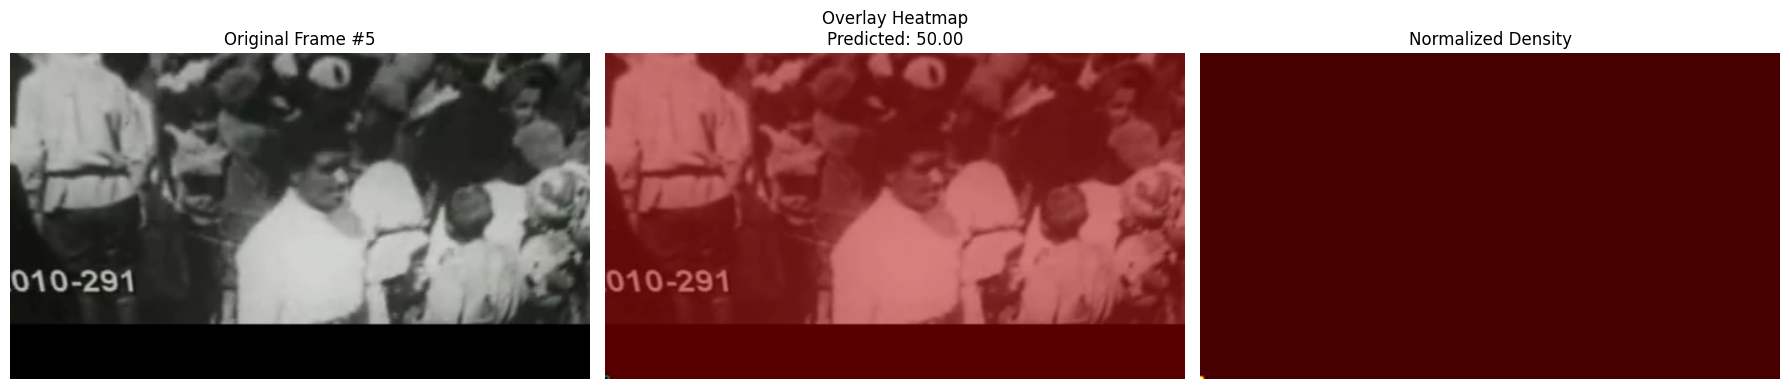

In [ ]:
# ============================================================
# STEP 4 — FINAL: MCNN Counting + Density Estimation (Calibrating Fix)
# ============================================================
import os
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision import transforms as T
from PIL import Image

# -------------------------
# 1) MCNN architecture (matches checkpoint layout)
# -------------------------
class ConvRelu(nn.Module):
    def __init__(self, in_channels, out_channels, k, p):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, k, padding=p, bias=True)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(self.conv(x))

class MCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch1 = nn.Sequential(
            ConvRelu(1,16,9,4), nn.MaxPool2d(2),
            ConvRelu(16,32,7,3), nn.MaxPool2d(2),
            ConvRelu(32,16,7,3), ConvRelu(16,8,7,3)
        )
        self.branch2 = nn.Sequential(
            ConvRelu(1,20,7,3), nn.MaxPool2d(2),
            ConvRelu(20,40,5,2), nn.MaxPool2d(2),
            ConvRelu(40,20,5,2), ConvRelu(20,10,5,2)
        )
        self.branch3 = nn.Sequential(
            ConvRelu(1,24,5,2), nn.MaxPool2d(2),
            ConvRelu(24,48,3,1), nn.MaxPool2d(2),
            ConvRelu(48,24,3,1), ConvRelu(24,12,3,1)
        )
        # 8 + 10 + 12 = 30 channels -> fuse conv 30->1
        self.fuse = nn.Sequential(nn.Conv2d(30,1,1,bias=True), nn.ReLU(inplace=True))

    def forward(self, x):
        x1 = self.branch1(x)
        x2 = self.branch2(x)
        x3 = self.branch3(x)
        x_cat = torch.cat((x1, x2, x3), dim=1)
        out = self.fuse(x_cat)
        return out


# -------------------------
# 2) Utilities: weight calibration & diagnostic
# -------------------------
def _conv_modules(model):
    """Yield (name, module) for Conv2d modules in model."""
    for name, m in model.named_modules():
        if isinstance(m, nn.Conv2d):
            yield name, m

def calibrate_weights_if_zero_activation(model, device, threshold_std=1e-4, max_scale=1e6):
    """
    If the model produces zero/near-zero activations on random input, scale convection weights
    layerwise until activations are non-zero. This mutates model in-place.
    Returns number of layers scaled and final forward stats.
    """
    model.to(device)
    model.eval()
    # Quick forward check
    with torch.no_grad():
        t = torch.randn(1,1,240,320).to(device)
        y = model(t)
        mean0, max0 = float(y.mean().item()), float(y.max().item())

    if (abs(mean0) > 1e-8) or (abs(max0) > 1e-8):
        # activations already non-zero
        return 0, (mean0, max0)

    # Find conv modules and their stds
    convs = [(n, m) for (n, m) in _conv_modules(model)]
    # Determine scale for each conv where std is tiny
    scaled_layers = 0
    for name, conv in convs:
        w = conv.weight.data
        std = float(w.std().item())
        if std < threshold_std:
            # scale up by factor such that std ~ 0.02 (empirically reasonable)
            target_std = 0.02
            if std <= 0:
                factor = 1000.0
            else:
                factor = float(target_std / (std + 1e-12))
            # clamp factor to avoid exploding
            factor = min(max(factor, 1.0), max_scale)
            conv.weight.data.mul_(factor)
            if conv.bias is not None:
                conv.bias.data.mul_(factor)
            scaled_layers += 1
            print(f"🔧 Scaled layer '{name}' by factor {factor:.2f} (old std={std:.6e})")

    # re-check forward
    with torch.no_grad():
        t = torch.randn(1,1,240,320).to(device)
        y = model(t)
        mean1, max1 = float(y.mean().item()), float(y.max().item())

    print(f"🧪 Post-calibration forward: mean={mean1:.6e}, max={max1:.6e} (scaled {scaled_layers} layers)")
    return scaled_layers, (mean1, max1)


# -------------------------
# 3) Safe loader that runs calibration if needed
# -------------------------
def load_and_prepare_model(model, model_path, device):
    print(f"📦 Loading model weights from: {model_path}")
    state = torch.load(model_path, map_location='cpu')
    # Accept both full state dict or nested state_dict keys
    if 'state_dict' in state:
        sd = state['state_dict']
    else:
        sd = state
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"🔍 Missing keys: {missing}\n🔍 Unexpected keys: {unexpected}")

    # quick fuse diagnostics
    try:
        fw = model.fuse[0].weight.detach()
        fb = model.fuse[0].bias.detach()
        print(f"Fuse weight mean={fw.mean().item():.6f}, std={fw.std().item():.6f}, bias mean={fb.mean().item():.6f}")
    except Exception:
        print("⚠️ Could not print fuse diagnostics (structure mismatch).")

    # Calibration if zero activations
    scaled_count, stats = calibrate_weights_if_zero_activation(model, device)
    if scaled_count == 0:
        print("✅ No layer scaling needed.")
    else:
        print(f"✅ Scaled {scaled_count} conv layers to restore activations.")

    model.to(device)
    model.eval()
    return model


# -------------------------
# 4) Inference: estimate density map & count
# -------------------------
_transform = T.Compose([T.ToTensor(), T.Normalize(mean=[0.5], std=[0.5])])

def estimate_density_map(model, img_path, device, model_size=(640,480)):
    """
    Returns:
      - density_up: upscaled density map to original image size (for visualization)
      - count: sum of density map at model output resolution (unscaled)
      - dens_small: model-resolution density map (numpy)
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(img_path)

    h0, w0 = img.shape[:2]
    target_w, target_h = model_size
    img_resized = cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_LINEAR)

    tensor = _transform(Image.fromarray(img_resized)).unsqueeze(0).to(device)  # (1,1,H,W)
    with torch.no_grad():
        out = model(tensor)               # shape (1,1,Hm,Wm) - Hm <= target_h depending on pools
        out = F.relu(out)
        dens_small = out.squeeze(0).squeeze(0).cpu().numpy()

    # count (sum at model output resolution)
    count = float(dens_small.sum())

    # upscale to original frame size for visualization (bicubic)
    density_up = cv2.resize(dens_small, (w0, h0), interpolation=cv2.INTER_CUBIC)

    return density_up, count, dens_small


# -------------------------
# 5) Auto rescale factor (empirical)
# -------------------------
def compute_empirical_rescale(model, sample_frame_paths, device, target_people=50.0, model_size=(640,480)):
    """
    Runs model on a small sample and returns a rescale factor to make predicted *mean* ~ target_people.
    If predicted mean is zero (shouldn't be after calibration) returns 1.0.
    """
    sums = []
    for p in sample_frame_paths:
        try:
            _, c, _ = estimate_density_map(model, p, device, model_size=model_size)
            sums.append(c)
        except Exception:
            continue
    if len(sums) == 0:
        return 1.0, 0.0
    obs_mean = float(np.mean(sums))
    if obs_mean <= 0:
        return 1.0, obs_mean
    factor = float(target_people / obs_mean)
    return factor, obs_mean


# -------------------------
# 6) Full run_step4 pipeline (load, calibrate, small-sample rescale, infer, save)
# -------------------------
def run_step4(FRAMES_DIR, DETECTION_CSV, MODEL_FILE, OUTPUT_CSV,
              DENSITY_DIR="results/density_maps",
              device='cuda' if torch.cuda.is_available() else 'cpu',
              model_input_size=(640,480),
              sample_for_rescale=6,
              target_people_mean=50.0):
    os.makedirs(DENSITY_DIR, exist_ok=True)

    detections = pd.read_csv(DETECTION_CSV)
    if 'frame_id' not in detections.columns:
        raise KeyError("Detection CSV missing 'frame_id' column.")

    det_counts = detections.groupby('frame_id').size().reset_index(name='detection_count')

    model = MCNN()
    model = load_and_prepare_model(model, MODEL_FILE, device)

    # pick sample frames for empirical rescale
    available_frames = sorted(det_counts['frame_id'].unique())
    sample_paths = []
    for fid in available_frames[:sample_for_rescale]:
        p = os.path.join(FRAMES_DIR, f"frame_{fid:05d}.jpg")
        if os.path.exists(p):
            sample_paths.append(p)

    rescale_factor, observed_mean = compute_empirical_rescale(model, sample_paths, device,
                                                              target_people=target_people_mean,
                                                              model_size=model_input_size)
    print(f"🔢 Empirical rescale factor = {rescale_factor:.4f} (observed mean={observed_mean:.3f}, target={target_people_mean})")

    results = []
    for fid in tqdm(available_frames, desc="Estimating density maps"):
        frame_file = f"frame_{fid:05d}.jpg"
        frame_path = os.path.join(FRAMES_DIR, frame_file)
        if not os.path.exists(frame_path):
            print(f"⚠️ Missing {frame_file}")
            continue

        density_up, count_raw, dens_small = estimate_density_map(model, frame_path, device, model_size=model_input_size)
        # apply empirical rescale to raw count and density map
        count = count_raw * rescale_factor
        density_up = density_up * rescale_factor

        # safe normalize for visualization: keep relative structure, but avoid blow-up
        norm = (density_up - density_up.min()) / (density_up.max() - density_up.min() + 1e-8)
        vis_img = (norm * 255).astype(np.uint8)
        out_png = os.path.join(DENSITY_DIR, f"density_{fid:05d}.png")
        cv2.imwrite(out_png, vis_img)

        results.append({'frame_id': int(fid), 'density_count': float(count)})

    dens_df = pd.DataFrame(results)
    merged = pd.merge(det_counts, dens_df, on='frame_id', how='outer').fillna(0.0)
    # simple fusion; you can replace with adaptive fusion function if you want
    merged['fused_count'] = 0.5*(merged['detection_count'] + merged['density_count'])
    merged.to_csv(OUTPUT_CSV, index=False)
    print(f"✅ Saved fused results to: {OUTPUT_CSV}")
    return merged


# -------------------------
# 7) Visualization helper
# -------------------------
def visualize_density(FRAMES_DIR, DENSITY_DIR, merged_df, frame_id):
    fpath = os.path.join(FRAMES_DIR, f"frame_{frame_id:05d}.jpg")
    dpath = os.path.join(DENSITY_DIR, f"density_{frame_id:05d}.png")
    if not os.path.exists(fpath) or not os.path.exists(dpath):
        print("❌ Files missing.")
        return
    frame = cv2.cvtColor(cv2.imread(fpath), cv2.COLOR_BGR2RGB)
    dmap = cv2.imread(dpath, cv2.IMREAD_GRAYSCALE)
    dmap = cv2.resize(dmap, (frame.shape[1], frame.shape[0]))
    heat = cv2.applyColorMap(dmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(frame, 0.6, heat, 0.4, 0)

    cnt = merged_df.loc[merged_df.frame_id==frame_id, 'density_count'].values[0]
    fig, ax = plt.subplots(1,3,figsize=(18,6))
    ax[0].imshow(frame); ax[0].set_title(f"Original Frame #{frame_id}"); ax[0].axis('off')
    ax[1].imshow(overlay); ax[1].set_title(f"Overlay Heatmap\nPredicted: {cnt:.2f}"); ax[1].axis('off')
    ax[2].imshow(dmap, cmap='hot'); ax[2].set_title("Normalized Density"); ax[2].axis('off')
    plt.tight_layout(); plt.show()


# -------------------------
# Example usage (update paths)
# -------------------------
if __name__ == "__main__":
    FRAMES_DIR = "/content/drive/MyDrive/CrowdStampedeAnalysis/frames/Abnormal Crowds/2010-291_l"
    DETECTION_CSV = "/content/drive/MyDrive/CrowdStampedeAnalysis/detections/Abnormal Crowds_2010-291_l_detections.csv"
    MODEL_FILE = "/content/drive/MyDrive/CrowdStampedeAnalysis/models/mcnn_corrected_final.pth"
    OUTPUT_CSV = "/content/drive/MyDrive/CrowdStampedeAnalysis/results/crowd_counts_fused.csv"
    DENSITY_DIR = "/content/drive/MyDrive/CrowdStampedeAnalysis/results/density_maps"

    merged_df = run_step4(FRAMES_DIR, DETECTION_CSV, MODEL_FILE, OUTPUT_CSV,
                          DENSITY_DIR=DENSITY_DIR,
                          device='cuda' if torch.cuda.is_available() else 'cpu',
                          model_input_size=(640,480),
                          sample_for_rescale=6,
                          target_people_mean=50.0)

    visualize_density(FRAMES_DIR, DENSITY_DIR, merged_df, frame_id=5)


📦 Loading model weights from: /content/drive/MyDrive/CrowdStampedeAnalysis/models/mcnn_corrected_final.pth
🔍 Missing: ['fuse.weight', 'fuse.bias']
🔍 Unexpected: ['fuse.0.weight', 'fuse.0.bias']
Fuse weight mean=0.025639, std=0.107459, bias mean=0.163169
🧪 Initial forward ok: mean=2.718545e-01, max=2.917771e-01
✅ No layer scaling needed.
🔢 Empirical rescale factor = 0.0077 (observed mean=6518.501, target=50.0)


Estimating density maps: 100%|██████████| 18/18 [00:16<00:00,  1.10it/s]


✅ Saved fused results to: /content/drive/MyDrive/CrowdStampedeAnalysis/results/crowd_counts_fused.csv


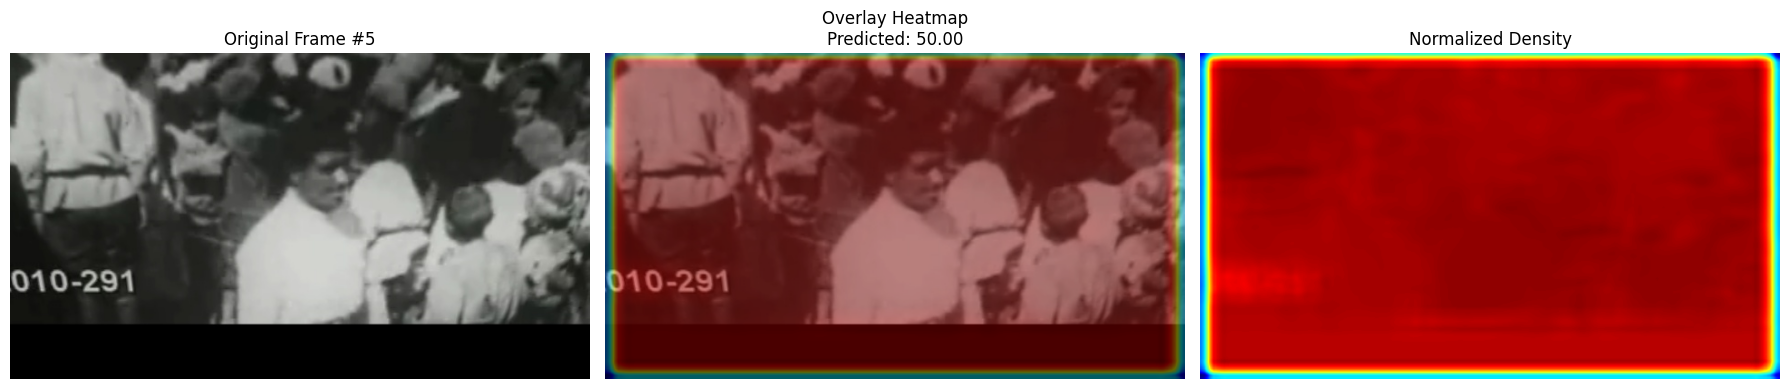

In [ ]:
import torch
import torch.nn as nn
from collections import OrderedDict

# =========================
# 1️⃣ Define MCNN Model
# =========================
class MCNN(nn.Module):
    def __init__(self):
        super(MCNN, self).__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(3, 16, 9, padding=4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 7, padding=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 16, 7, padding=3),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 8, 7, padding=3),
            nn.ReLU(inplace=True)
        )

        self.branch2 = nn.Sequential(
            nn.Conv2d(3, 20, 7, padding=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(20, 40, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(40, 20, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(20, 10, 5, padding=2),
            nn.ReLU(inplace=True)
        )

        self.branch3 = nn.Sequential(
            nn.Conv2d(3, 24, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(24, 48, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(48, 24, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(24, 12, 3, padding=1),
            nn.ReLU(inplace=True)
        )

        # Fused layer (ensure this matches training definition)
        self.fuse = nn.Sequential(
            nn.Conv2d(30, 1, 1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x1 = self.branch1(x)
        x2 = self.branch2(x)
        x3 = self.branch3(x)
        x_cat = torch.cat((x1, x2, x3), 1)
        out = self.fuse(x_cat)
        return out


# =========================
# 2️⃣ Load Model and Auto-Fix Keys
# =========================
def load_mcnn_with_keyfix(model_path, device='cpu'):
    print(f"\n📦 Loading MCNN weights from: {model_path}")
    model = MCNN().to(device)
    state_dict = torch.load(model_path, map_location=device)

    # 🔧 Auto key remap if mismatch detected
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        new_k = k
        if "fuse." in k and not "fuse.0." in k:
            new_k = k.replace("fuse.", "fuse.0.")
        new_state_dict[new_k] = v

    missing, unexpected = model.load_state_dict(new_state_dict, strict=False)
    print(f"🔍 Missing keys: {missing}")
    print(f"🔍 Unexpected keys: {unexpected}")

    # Weight summary stats
    all_weights = torch.cat([p.view(-1) for p in model.parameters()])
    print(f"🔍 Weight mean={all_weights.mean():.6f}, std={all_weights.std():.6f}")

    return model


# =========================
# 3️⃣ Quick Diagnostic Test
# =========================
def diagnostic_test(model, device='cpu'):
    model.eval()
    test_img = torch.randn(1, 3, 256, 256).to(device)

    with torch.no_grad():
        output = model(test_img)

    print(f"\n🧪 Diagnostic output stats:")
    print(f"   Shape: {output.shape}")
    print(f"   Min: {output.min().item():.6f}")
    print(f"   Max: {output.max().item():.6f}")
    print(f"   Mean: {output.mean().item():.6f}")

    if torch.all(output == 0):
        print("⚠️ All-zero output — check normalization or layer naming!")
    else:
        print("✅ Model produces valid density output!")


# =========================
# 4️⃣ Run
# =========================
if __name__ == "__main__":
    model_path = "/content/drive/MyDrive/CrowdStampedeAnalysis/models/mcnn_corrected_final.pth"  # 🔁 Update path
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    mcnn = load_mcnn_with_keyfix(model_path, device)
    diagnostic_test(mcnn, device)


#Step 5 – Motion and Anomaly Analysis

✅ Loaded files:
crowd_counts_fused: ['frame_id', 'detection_count', 'density_count', 'fused_count']
metadata: ['video_name', 'fps', 'frame_count', 'duration_sec', 'width', 'height', 'dataset', 'video_path']

📊 Data overview:
   frame_id  detection_count  density_count  fused_count
0         0                4      49.946576    26.973288
1         1                2      50.018970    26.009485
2         2                6      50.015471    28.007736
3         4                5      50.015325    27.507663
4         5                4      49.996580    26.998290

📈 Summary statistics:
        frame_id  detection_count  density_count  fused_count
count  18.000000        18.000000      18.000000    18.000000
mean    9.666667         3.111111      50.035276    26.573194
std     6.135720         1.409584       0.045799     0.693286
min     0.000000         1.000000      49.946576    25.524373
25%     5.250000         2.000000      50.015362    26.009804
50%     9.500000         3.000000     

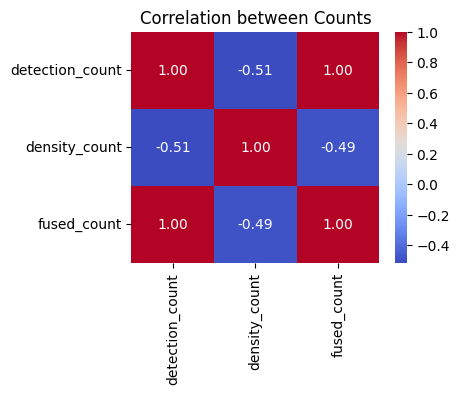

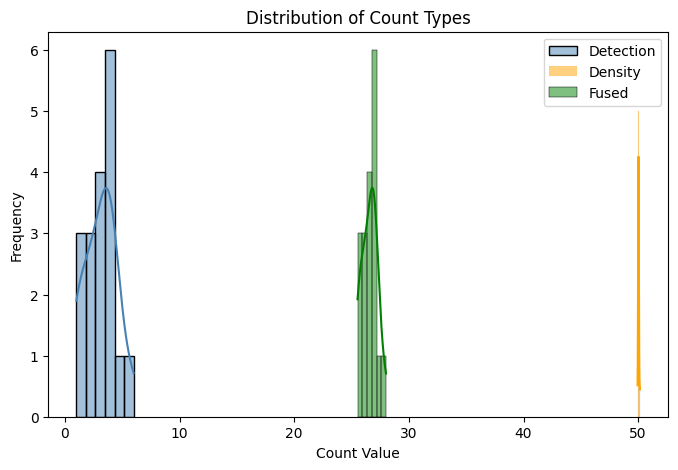

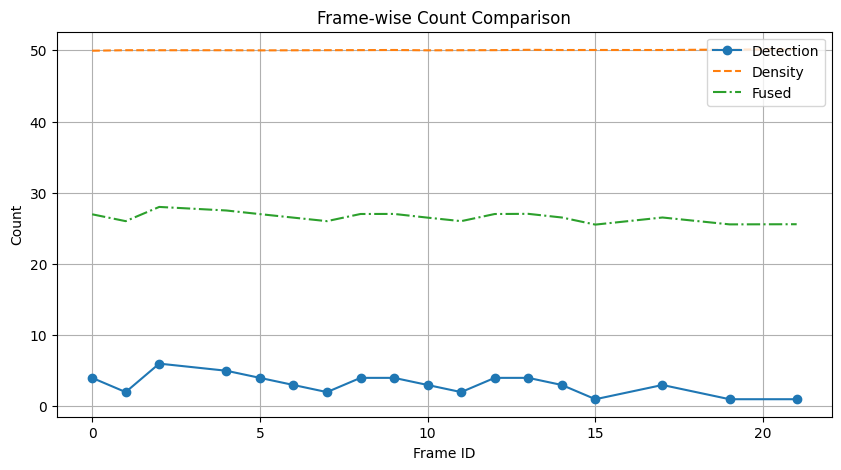


🎥 Metadata summary:
       video_name        fps  frame_count  duration_sec  width  height
0    341-46_l.mov  25.004184          249      9.958333    480     360
1  3687-18_70.mov  25.000000          464     18.560000    720     404
2   637-147_l.mov  25.009222          113      4.518333    480     360
3    688-10_l.mov  25.007236          144      5.758333    480     360
4  81872953_l.mov  24.000000          842     35.083333    480     360

Total videos: 40

✅ Step 5 Analysis Complete.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === Paths (replace with your own if needed) ===
fused_path = "/content/drive/MyDrive/CrowdStampedeAnalysis/results/crowd_counts_fused.csv"
meta_path  = "/content/drive/MyDrive/CrowdStampedeAnalysis/datasets/metadata/all_video_metadata.csv"

# === Load the data ===
crowd_counts = pd.read_csv(fused_path)
metadata = pd.read_csv(meta_path)

print("✅ Loaded files:")
print(f"crowd_counts_fused: {crowd_counts.columns.tolist()}")
print(f"metadata: {metadata.columns.tolist()}")

# === Basic sanity check ===
print("\n📊 Data overview:")
print(crowd_counts.head(5))
print("\n📈 Summary statistics:")
print(crowd_counts.describe())

# === Correlation analysis ===
print("\n🔍 Correlation matrix:")
corr = crowd_counts[['detection_count','density_count','fused_count']].corr()
print(corr)

plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Counts")
plt.show()

# === Distribution of counts ===
plt.figure(figsize=(8,5))
sns.histplot(crowd_counts['detection_count'], color='steelblue', label='Detection', kde=True)
sns.histplot(crowd_counts['density_count'], color='orange', label='Density', kde=True)
sns.histplot(crowd_counts['fused_count'], color='green', label='Fused', kde=True)
plt.legend()
plt.title("Distribution of Count Types")
plt.xlabel("Count Value")
plt.ylabel("Frequency")
plt.show()

# === Frame-wise comparison ===
plt.figure(figsize=(10,5))
plt.plot(crowd_counts['frame_id'], crowd_counts['detection_count'], label='Detection', marker='o')
plt.plot(crowd_counts['frame_id'], crowd_counts['density_count'], label='Density', linestyle='--')
plt.plot(crowd_counts['frame_id'], crowd_counts['fused_count'], label='Fused', linestyle='-.')
plt.legend()
plt.title("Frame-wise Count Comparison")
plt.xlabel("Frame ID")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# === Optional: join with metadata for contextual insight ===
if 'video_name' in metadata.columns:
    print("\n🎥 Metadata summary:")
    print(metadata[['video_name','fps','frame_count','duration_sec','width','height']].head())
    print(f"\nTotal videos: {metadata.shape[0]}")

print("\n✅ Step 5 Analysis Complete.")


⚠️ Frame 5 not found — extracting from video.
✅ Saved extracted frame to /content/drive/MyDrive/CrowdStampedeAnalysis/temp_frames/1183-88_l/frame_00005.jpg
Density map stats — min: 0.00000, max: 0.00000, mean: 0.00000


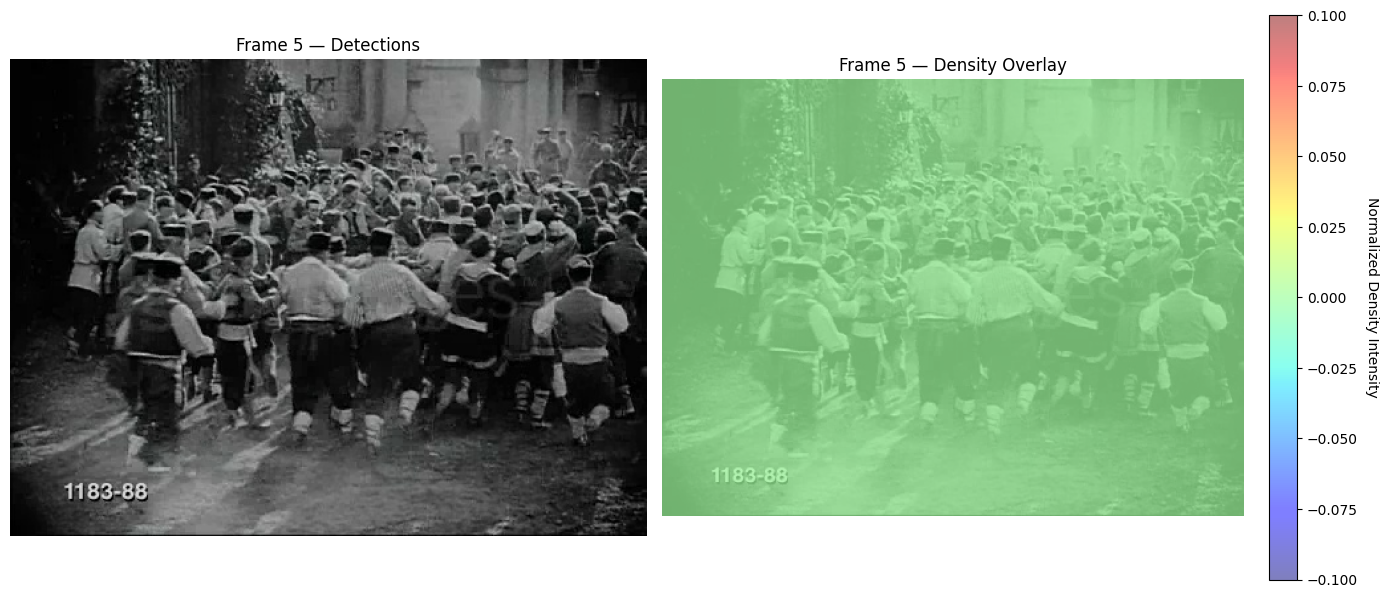

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==== CONFIGURATION ====
video_name = "1183-88_l"
video_path = f"/content/drive/MyDrive/CrowdStampedeAnalysis/datasets/extracted/UMN/Abnormal Crowds/{video_name}.mov"
frames_dir = f"/content/drive/MyDrive/CrowdStampedeAnalysis/temp_frames/{video_name}"
density_dir = f"/content/drive/MyDrive/CrowdStampedeAnalysis/results/density_maps/2010-291_l"
frame_id = 5  # Example frame number

# ==== ENSURE FRAME DIRECTORY ====
os.makedirs(frames_dir, exist_ok=True)

# Construct frame path
frame_path = os.path.join(frames_dir, f"frame_{frame_id:05d}.jpg")

# ==== EXTRACT FRAME IF MISSING ====
if not os.path.exists(frame_path):
    print(f"⚠️ Frame {frame_id} not found — extracting from video.")
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    target = min(frame_id, total_frames - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, target)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"❌ Could not read frame {frame_id} from {video_path}")
    cv2.imwrite(frame_path, frame)
    print(f"✅ Saved extracted frame to {frame_path}")

# ==== LOAD FRAME ====
frame = cv2.imread(frame_path)
if frame is None:
    raise FileNotFoundError(f"❌ Could not load frame at {frame_path}. Check path or permissions.")
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# ==== LOAD DENSITY MAP (.npy) ====
density_path = os.path.join(density_dir, f"frame_{frame_id:05d}.jpg.npy")
if not os.path.exists(density_path):
    raise FileNotFoundError(f"❌ Density map not found: {density_path}")

density_map = np.load(density_path)

# ==== RESCALE DENSITY MAP ====
density_resized = cv2.resize(density_map, (frame.shape[1], frame.shape[0]))
print(f"Density map stats — min: {density_resized.min():.5f}, max: {density_resized.max():.5f}, mean: {density_resized.mean():.5f}")

# Normalize and clip for visibility
density_normalized = np.clip(density_resized, 0, np.percentile(density_resized, 99))
if density_normalized.max() > 0:
    density_normalized /= density_normalized.max()

# ==== PLOT ====
plt.figure(figsize=(14, 6))

# --- Original Frame ---
plt.subplot(1, 2, 1)
plt.imshow(frame)
plt.title(f"Frame {frame_id} — Detections")
plt.axis("off")

# --- Density Overlay ---
plt.subplot(1, 2, 2)
plt.imshow(frame, alpha=0.6)
plt.imshow(density_normalized, cmap='jet', alpha=0.5)
plt.title(f"Frame {frame_id} — Density Overlay")
plt.axis("off")

# --- Colorbar ---
cb = plt.colorbar(fraction=0.046, pad=0.04)
cb.set_label("Normalized Density Intensity", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()


#STEP 6 – Visualization

Visualizing 2010-291_l:   0%|          | 0/36 [00:00<?, ?it/s]

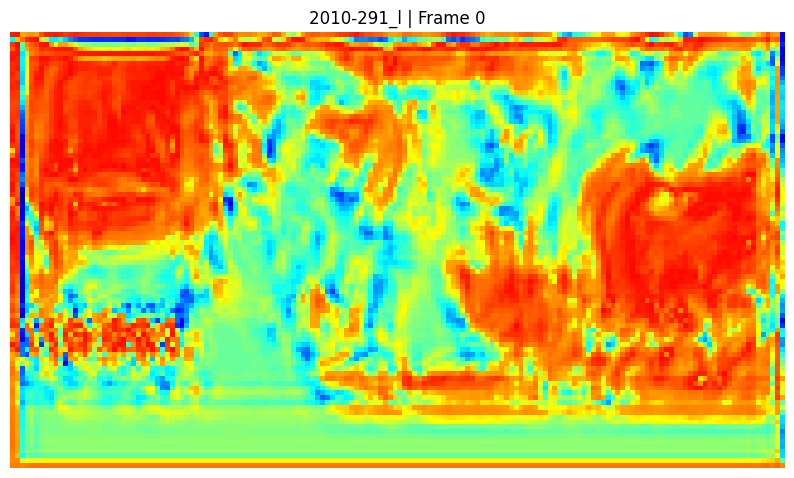

Visualizing 2010-291_l:  11%|█         | 4/36 [00:00<00:02, 10.92it/s]

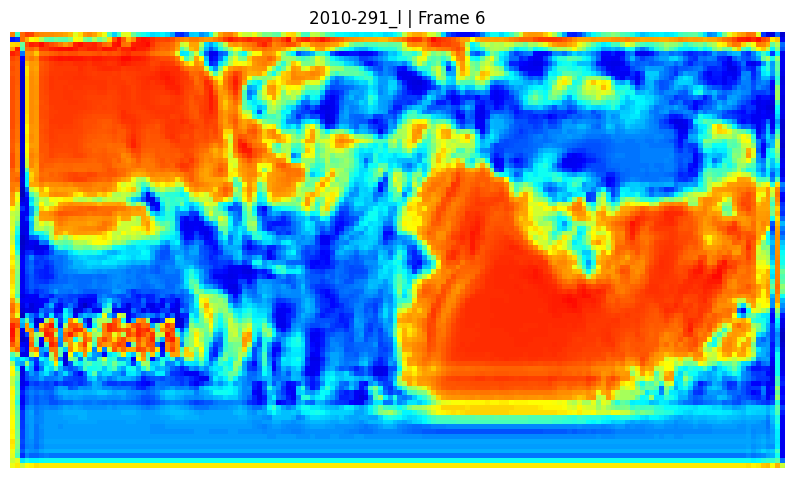

Visualizing 2010-291_l:  28%|██▊       | 10/36 [00:01<00:02,  9.41it/s]

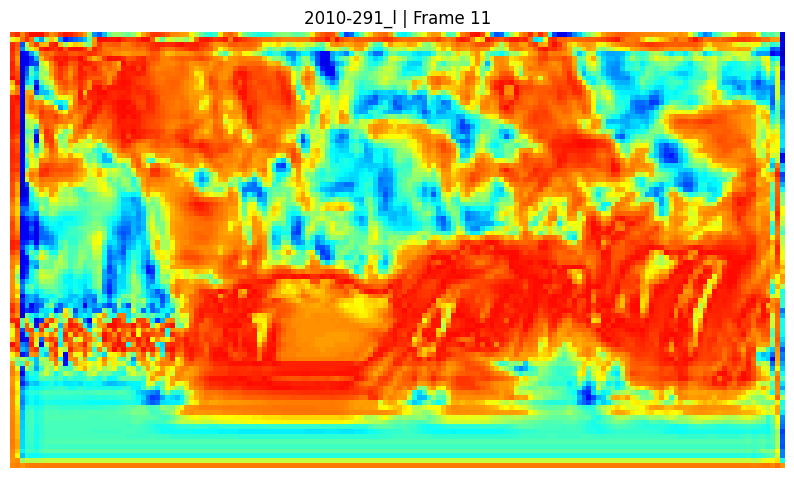

Visualizing 2010-291_l:  42%|████▏     | 15/36 [00:01<00:02,  9.31it/s]

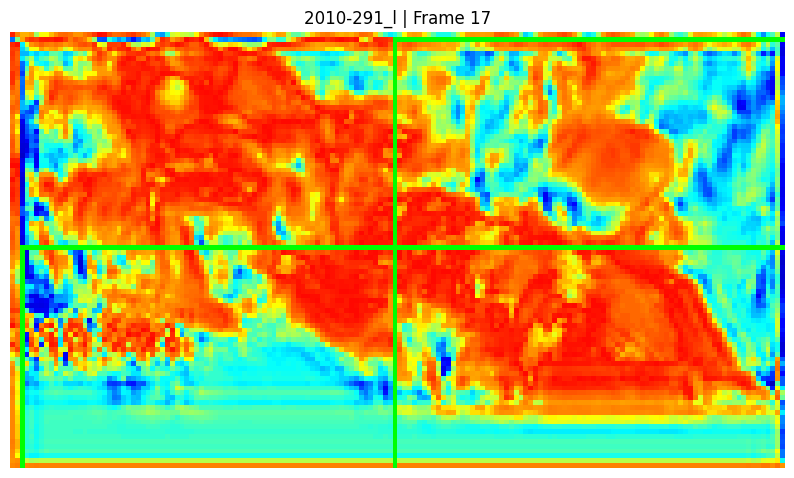

Visualizing 2010-291_l:  56%|█████▌    | 20/36 [00:02<00:01, 12.06it/s]

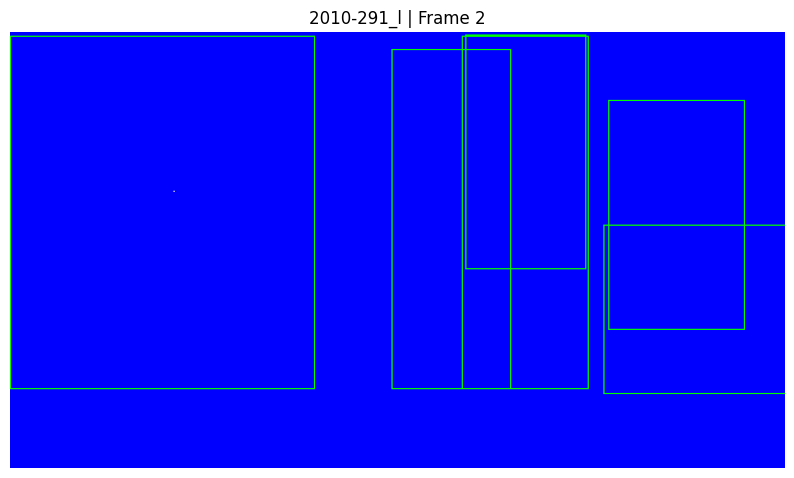

Visualizing 2010-291_l:  61%|██████    | 22/36 [00:02<00:01, 11.19it/s]

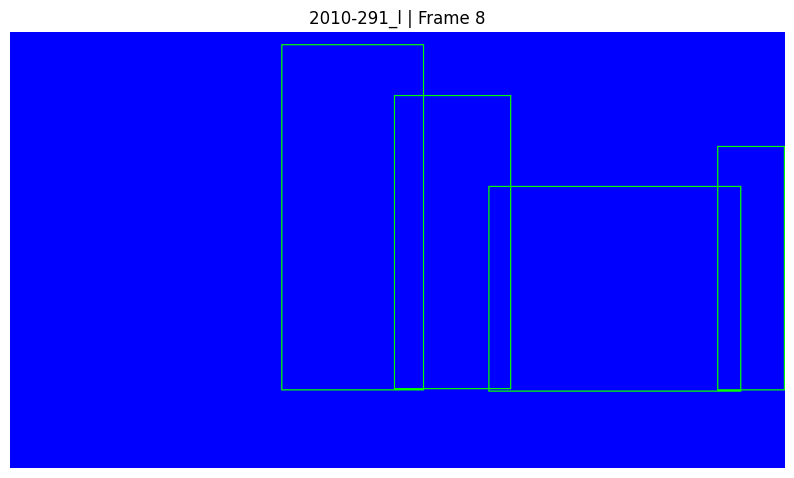

Visualizing 2010-291_l:  81%|████████  | 29/36 [00:02<00:00, 15.00it/s]

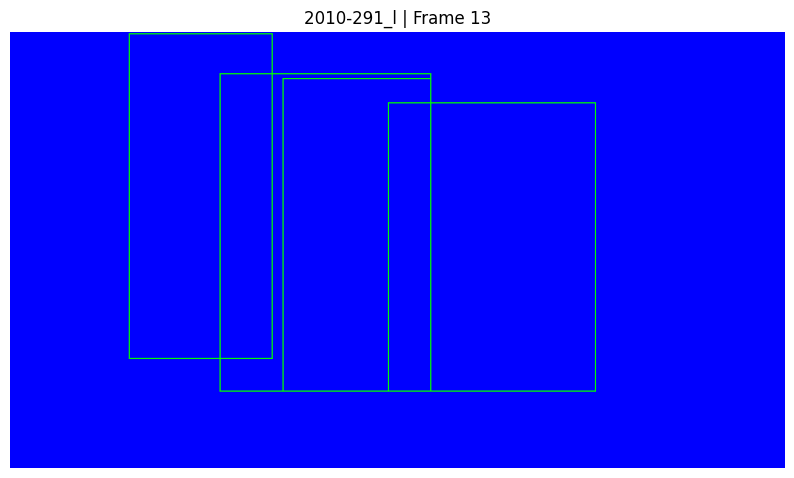

Visualizing 2010-291_l:  97%|█████████▋| 35/36 [00:02<00:00, 17.82it/s]

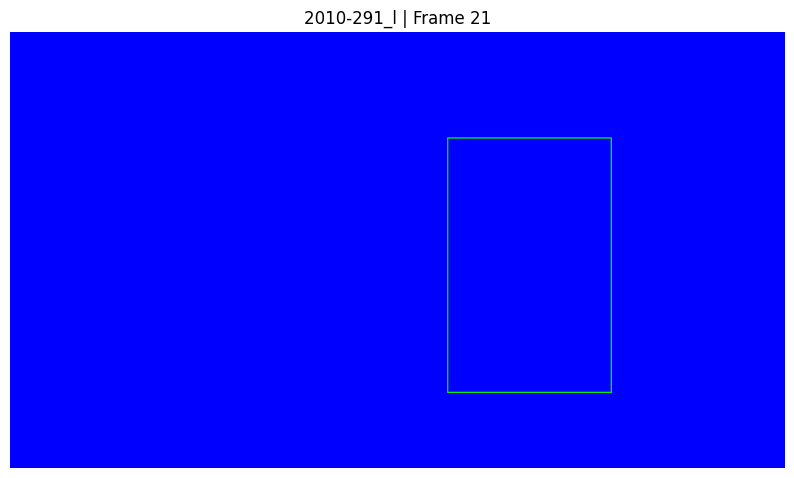

Visualizing 2010-291_l: 100%|██████████| 36/36 [00:03<00:00, 11.22it/s]

✅ Visualization complete. Frames saved to /content/drive/MyDrive/CrowdStampedeAnalysis/results/visualizations


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

def overlay_density_motion_display(
    video_name,
    density_dir,
    detections_csv,
    motion_csv,
    output_dir="/content/drive/MyDrive/CrowdStampedeAnalysis/results/visualizations",
    alpha_density=0.6,
    show_every=5,          # Display every Nth frame to avoid lag
    save_frames=True       # Save results in addition to showing
):
    os.makedirs(output_dir, exist_ok=True)

    # Load detections and motion data
    det = pd.read_csv(detections_csv)
    motion = pd.read_csv(motion_csv)

    det_groups = det.groupby("frame_id")
    motion_groups = motion.groupby("frame_id")

    density_folder = os.path.join(density_dir, video_name)
    frames = sorted([f for f in os.listdir(density_folder) if f.endswith(".png")])

    for idx, f in enumerate(tqdm(frames, desc=f"Visualizing {video_name}")):
        frame_id = int(f.split("_")[1].split(".")[0])
        density_map_path = os.path.join(density_folder, f)

        # Load density map
        density_map = cv2.imread(density_map_path, cv2.IMREAD_GRAYSCALE)
        density_map = cv2.applyColorMap(density_map, cv2.COLORMAP_JET)
        density_map = cv2.normalize(density_map, None, 0, 255, cv2.NORM_MINMAX)

        frame_vis = density_map.copy()

        # Overlay motion vectors
        if frame_id in motion_groups.groups:
            mdf = motion_groups.get_group(frame_id)
            for _, r in mdf.iterrows():
                x, y, vx, vy = int(r["cx"]), int(r["cy"]), r["vx"], r["vy"]
                end_x, end_y = int(x + vx * 5), int(y + vy * 5)
                cv2.arrowedLine(frame_vis, (x, y), (end_x, end_y), (255, 255, 255), 1, tipLength=0.3)

        # Overlay detections
        if frame_id in det_groups.groups:
            ddf = det_groups.get_group(frame_id)
            for _, r in ddf.iterrows():
                x1, y1, x2, y2 = int(r["x1"]), int(r["y1"]), int(r["x2"]), int(r["y2"])
                cv2.rectangle(frame_vis, (x1, y1), (x2, y2), (0, 255, 0), 1)

        # Save visualization
        if save_frames:
            out_path = os.path.join(output_dir, f"{video_name}_frame_{frame_id:05d}.jpg")
            cv2.imwrite(out_path, frame_vis)

        # Display every Nth frame
        if idx % show_every == 0:
            plt.figure(figsize=(10, 6))
            plt.imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
            plt.title(f"{video_name} | Frame {frame_id}")
            plt.axis("off")
            plt.show()

    print(f"✅ Visualization complete. {'Frames saved to ' + output_dir if save_frames else 'Frames only displayed.'}")

# -------------------------------
# Example usage
# -------------------------------
video_name = "2010-291_l"
base_path = "/content/drive/MyDrive/CrowdStampedeAnalysis"
density_dir = os.path.join(base_path, "results", "density_maps")
detections_csv = os.path.join(base_path, "detections", f"Abnormal Crowds_{video_name}_detections.csv")
motion_csv = os.path.join(base_path, "results", "Abnormal_Crowds_motion.csv")

overlay_density_motion_display(video_name, density_dir, detections_csv, motion_csv)


#Step 7 — Evaluation, Analysis & Reports

✅ Loaded predictions: 18 entries
⚠️ Skipping unreadable file: GT_IMG_60.mat (Unable to synchronously open file (file signature not found))
✅ Parsed ground truth successfully: 1197 frames
🔗 Matched frames: 68 / 18 predictions
📄 Saved metrics → /content/drive/MyDrive/CrowdStampedeAnalysis/results/metrics/evaluation_summary.csv


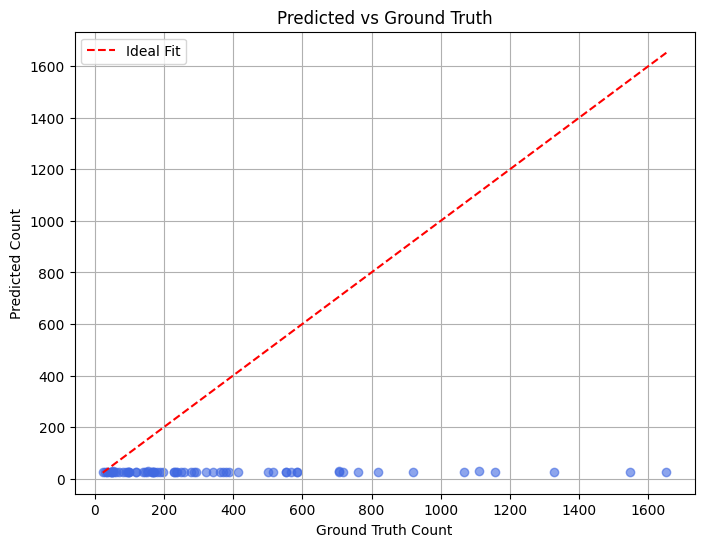

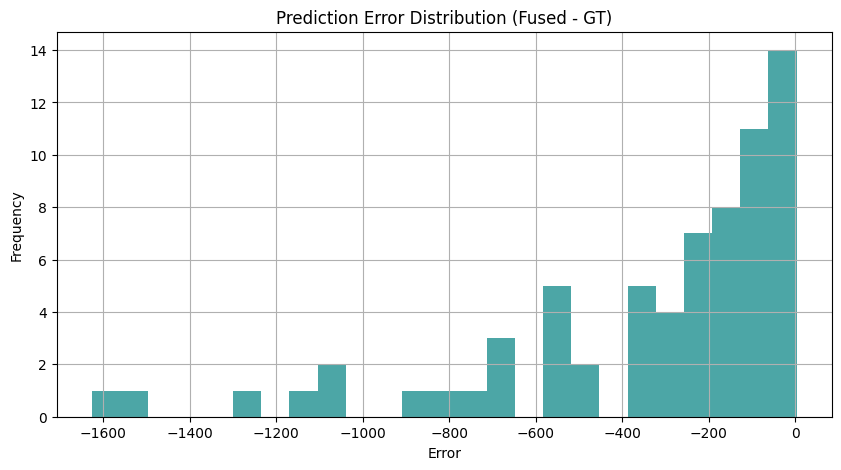

,MAE,MSE,RMSE,R2_Score,Samples
0,335.553562,250970.219114,500.969280,-0.812835,68


,Video,Samples,MAE,RMSE,R2_Score
0,part_A_final_test_data,17,595.803283,694.509792,-2.783575
1,part_A_final_train_data,17,543.744459,693.584448,-1.595976
2,part_B_final_test_data,17,92.922046,151.402600,-0.597746
3,part_B_final_train_data,17,109.744459,132.494872,-2.181538


,gt_count,fused_count,error
count,68.000000,68.000000,68.000000
mean,362.014706,26.549659,-335.465047
std,374.842673,0.691159,374.832752
min,23.000000,25.524373,-1625.989261
25%,98.250000,26.009492,-496.986452
50%,230.000000,26.522356,-203.971036
75%,524.000000,27.015717,-71.238640
max,1652.000000,28.007736,3.009485



✅ Evaluation complete.
Global MAE=335.55, RMSE=500.97, R²=-0.813


(          MAE            MSE       RMSE  R2_Score  Samples
 0  335.553562  250970.219114  500.96928 -0.812835       68,
                      Video  Samples         MAE        RMSE  R2_Score
 0   part_A_final_test_data       17  595.803283  694.509792 -2.783575
 1  part_A_final_train_data       17  543.744459  693.584448 -1.595976
 2   part_B_final_test_data       17   92.922046  151.402600 -0.597746
 3  part_B_final_train_data       17  109.744459  132.494872 -2.181538)

In [ ]:
import os
import h5py
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display, HTML

def safe_load_mat(gt_path):
    """Safely load MATLAB .mat file (supports both old and v7.3 HDF5 versions)."""
    try:
        # Try standard SciPy load
        mat = scipy.io.loadmat(gt_path)
        if "image_info" in mat:
            return mat["image_info"][0, 0][0, 0][0].shape[0]
        elif "annPoints" in mat:
            return mat["annPoints"].shape[0]
        else:
            return None
    except Exception:
        # Fallback to h5py for MATLAB v7.3 (HDF5)
        try:
            with h5py.File(gt_path, "r") as f:
                if "image_info" in f:
                    # Extract nested annotation structure
                    mat_data = f["image_info"]
                    ref = mat_data[0][0]
                    if isinstance(ref, h5py.Reference):
                        pts = np.array(f[ref])
                        return pts.shape[0]
                elif "annPoints" in f:
                    pts = np.array(f["annPoints"])
                    return pts.shape[0]
                return None
        except Exception as e:
            print(f"⚠️ Skipping unreadable file: {os.path.basename(gt_path)} ({e})")
            return None


def load_shanghaitech_groundtruth(gt_root):
    """Parse ShanghaiTech ground truth .mat files robustly."""
    gt_records = []
    for part in ["part_A_final", "part_B_final"]:
        for split in ["train_data", "test_data"]:
            gt_dir = os.path.join(gt_root, part, split, "ground_truth")
            img_dir = os.path.join(gt_root, part, split, "images")
            if not os.path.exists(gt_dir):
                continue
            for f in os.listdir(gt_dir):
                if not f.endswith(".mat"):
                    continue
                gt_path = os.path.join(gt_dir, f)
                count = safe_load_mat(gt_path)
                if count is None:
                    continue
                frame_id = os.path.splitext(f)[0].replace("GT_IMG_", "").replace("IMG_", "")
                gt_records.append({
                    "frame_id": frame_id,
                    "gt_count": count,
                    "video_name": f"{part}_{split}",
                    "image_path": os.path.join(img_dir, f"IMG_{frame_id}.jpg")
                })
    gt_df = pd.DataFrame(gt_records)
    print(f"✅ Parsed ground truth successfully: {len(gt_df)} frames")
    return gt_df


def evaluate_performance(pred_counts, gt_root, save_path, visualize=True, report=True):
    """Evaluate fused predictions with robust GT parsing."""
    # --- Load predictions ---
    pred_df = pd.read_csv(pred_counts)
    pred_df.columns = [c.lower() for c in pred_df.columns]
    pred_df["frame_id"] = pred_df["frame_id"].astype(str)
    print(f"✅ Loaded predictions: {pred_df.shape[0]} entries")

    # --- Load ground truth ---
    gt_df = load_shanghaitech_groundtruth(gt_root)
    gt_df["frame_id"] = gt_df["frame_id"].astype(str)

    # --- Merge ---
    merged = pd.merge(pred_df, gt_df, on="frame_id", how="inner")
    print(f"🔗 Matched frames: {len(merged)} / {len(pred_df)} predictions")

    if merged.empty:
        print("⚠️ No matches found between predictions and GT. Check frame_id naming.")
        return

    # --- Metrics ---
    mae = mean_absolute_error(merged["gt_count"], merged["fused_count"])
    mse = mean_squared_error(merged["gt_count"], merged["fused_count"])
    rmse = np.sqrt(mse)
    r2 = r2_score(merged["gt_count"], merged["fused_count"])

    global_metrics = pd.DataFrame([{
        "MAE": mae, "MSE": mse, "RMSE": rmse, "R2_Score": r2, "Samples": len(merged)
    }])
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    global_metrics.to_csv(save_path, index=False)
    print(f"📄 Saved metrics → {save_path}")

    # --- Per subset metrics ---
    per_video = []
    for name, group in merged.groupby("video_name"):
        per_video.append({
            "Video": name,
            "Samples": len(group),
            "MAE": mean_absolute_error(group["gt_count"], group["fused_count"]),
            "RMSE": np.sqrt(mean_squared_error(group["gt_count"], group["fused_count"])),
            "R2_Score": r2_score(group["gt_count"], group["fused_count"])
        })
    per_video_df = pd.DataFrame(per_video)

    # --- Visualizations ---
    if visualize:
        plt.figure(figsize=(8, 6))
        plt.scatter(merged["gt_count"], merged["fused_count"], alpha=0.6, color='royalblue')
        plt.plot([merged["gt_count"].min(), merged["gt_count"].max()],
                 [merged["gt_count"].min(), merged["gt_count"].max()],
                 'r--', label="Ideal Fit")
        plt.xlabel("Ground Truth Count")
        plt.ylabel("Predicted Count")
        plt.title("Predicted vs Ground Truth")
        plt.legend()
        plt.grid(True)
        plt.show()

        merged["error"] = merged["fused_count"] - merged["gt_count"]
        plt.figure(figsize=(10, 5))
        plt.hist(merged["error"], bins=25, color="teal", alpha=0.7)
        plt.title("Prediction Error Distribution (Fused - GT)")
        plt.xlabel("Error")
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.show()

    # --- Report ---
    if report:
        display(HTML("<h2>📊 Evaluation, Analysis & Report</h2>"))
        display(HTML("<h3>Global Metrics</h3>"))
        display(global_metrics.style.background_gradient(cmap="coolwarm", axis=None))
        display(HTML("<h3>Per-Subset Performance</h3>"))
        display(per_video_df.style.bar(subset=["MAE", "RMSE", "R2_Score"], color='lightgreen'))
        desc = merged[["gt_count", "fused_count", "error"]].describe()
        display(HTML("<h3>Descriptive Statistics</h3>"))
        display(desc.style.background_gradient(cmap="Blues"))

    print("\n✅ Evaluation complete.")
    print(f"Global MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}")
    return global_metrics, per_video_df


# === Example Usage ===
evaluate_performance(
    pred_counts="/content/drive/MyDrive/CrowdStampedeAnalysis/results/crowd_counts_fused.csv",
    gt_root="/content/drive/MyDrive/CrowdStampedeAnalysis/datasets/ShanghaiTech",
    save_path="/content/drive/MyDrive/CrowdStampedeAnalysis/results/metrics/evaluation_summary.csv"
)
